# Network Construction

In [1]:
from src.system_discovery import SystemDiscovery

import collections
import os
import src.constants as cn
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
from src.biomodels_iterator import BiomodelsIterator
import sbmlnetwork as sb
import tellurium as te

# Helpers

In [2]:
TEST_MODEL = """
S0 -> S1; 1
S1 -> S2; S1
S2 ->; 0.5*S2

$S0 = 4
"""

## ``simulate``

In [30]:
def simulate(antimony_str: str, start_time:float=0, end_time:float=5.0, num_point:int=100,
        is_plot:bool = True) -> pd.DataFrame:
    rr = te.loada(antimony_str)
    species_names = np.sort(list(rr.getFloatingSpeciesIds()) + list(rr.getBoundarySpeciesIds()))
    selections = ["time"] + list(species_names)
    data_arr = rr.simulate(start_time, end_time, num_point, selections=selections)
    if is_plot:
        rr.plot()
    column_names = np.sort([c[1:-1] if c[0] == "[" else c for c in data_arr.colnames])
    data_df = pd.DataFrame(data_arr, columns=column_names)
    data_df = data_df.set_index("time")
    return data_df
# Tests
data_df = simulate(TEST_MODEL, is_plot=False)
assert(isinstance(data_df, pd.DataFrame))
print("OK!")

OK!


## ``fitNetwork``

In [4]:
FitResult = collections.namedtuple("FitResult", ["sd", "summary", "timecourse_df",
            "prediction_df", "poly_degree", "threshold"])
def fitNetwork(antimony_str:str, threshold: float = 0.01, num_point:int = 100,
            start_time:float = 0, end_time:float= 5,
              poly_degree:int = 2, is_plot:bool=True) -> FitResult:
    data_df = simulate(antimony_str,
            start_time=start_time, end_time=end_time, num_point=num_point,
            is_plot=False)
    system_discovery = SystemDiscovery(
        data_df,
       threshold=threshold,
        alpha=0.01,
        poly_degree=poly_degree,
        include_bias=True,
        differentiation="finite",
        is_normalize=True,
    ).fit()
    if is_plot:
        system_discovery.plotResult()
    return FitResult(sd=system_discovery, summary=system_discovery.summary(), timecourse_df=data_df,
            prediction_df=system_discovery.predict(),
            poly_degree=poly_degree, threshold=threshold)

# Tests
result = fitNetwork(TEST_MODEL, is_plot=False)
assert(isinstance(result.sd, SystemDiscovery))
assert(isinstance(result.summary, pd.DataFrame))
assert(isinstance(result.timecourse_df, pd.DataFrame))
assert(isinstance(result.prediction_df, pd.DataFrame))
assert(isinstance(result.poly_degree, int))
print("OK!")

OK!


## ``evaluateFit``

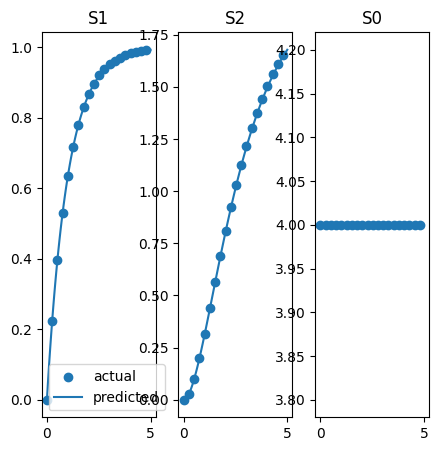

In [5]:
def evaluateFit(fit_result: FitResult, is_plot:bool = True):
    species_names = list(fit_result.timecourse_df.columns)
    num_species = len(species_names)
    timecourse_df = fit_result.timecourse_df
    prediction_df = fit_result.prediction_df
    # Create a grid of subplots
    num_column = min(num_species, 4)
    num_row = num_species // num_column
    if num_species % num_column != 0:
        num_row += 1
    fig, axes = plt.subplots(num_row, num_column, figsize=(5, 5))
    for iplot, species_name in enumerate(species_names):
        time_arr = np.array(timecourse_df.index)
        value_arr = timecourse_df[species_name].values
        axes[iplot].scatter(time_arr[::5], value_arr[::5])
        axes[iplot].plot(prediction_df.index, prediction_df[species_name])
        axes[iplot].set_title(species_name)
        if iplot == 0:
            axes[iplot].legend(["actual", "predicted"])
    # Remove unneeded plots
    for iplot in range(num_species, num_row*num_column):
        axes[iplot].set_visible(False)

# Tests
fit_result = fitNetwork(TEST_MODEL, is_plot=False)
evaluateFit(fit_result, is_plot=True)

## ``draw``

In [6]:
def draw(ant_str: str, is_plot:bool = True, path:str = ""):
    rr = te.loada(ant_str)
    sbml_str = rr.getSBML()
    net = sb.load(sbml_str)
    
    # Render the network and save a PNG
    net.set_size((50.0, 50.0))
    net.set_font_size(32)
    net.set_font_color("black")
    if len(path) > 0:
        net.draw(path)
    if is_plot:
        net.draw()

# Tests
draw(TEST_MODEL, is_plot=False, path="my.png")
draw(TEST_MODEL, is_plot=False)
print("OK!")

OK!


# Quadratic Networks

Below is Yejee's network.

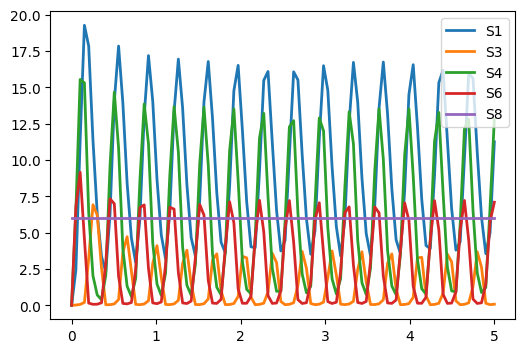

In [17]:
YJ_NET = """
$S8 -> S6; k0*S8
S1 -> S3; k2*S1
S3 + S6 ->; k4*S3*S6
S4 -> S1; k5*S4
S6 -> S6 + S4; k6*S6

k0 = 24; k2 = 15; k3 = 54; k4 = 315
k5 = 24; k6 = 53
S8 = 6.0
"""
rr = te.loada(YJ_NET)
DATA_YJ = rr.simulate(0, 5, 100, selections=['time', 'S1', 'S3', 'S4', 'S6', 'S8'])
rr.plot()
#draw(YJ_NET,"[/Users/jlheller/home/Technical/repos/model_linearity_analysis/yj_net1_orig.png")

Below is a simplification of the network Yeejee discovered

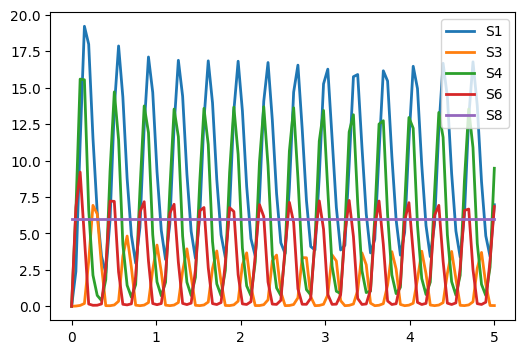

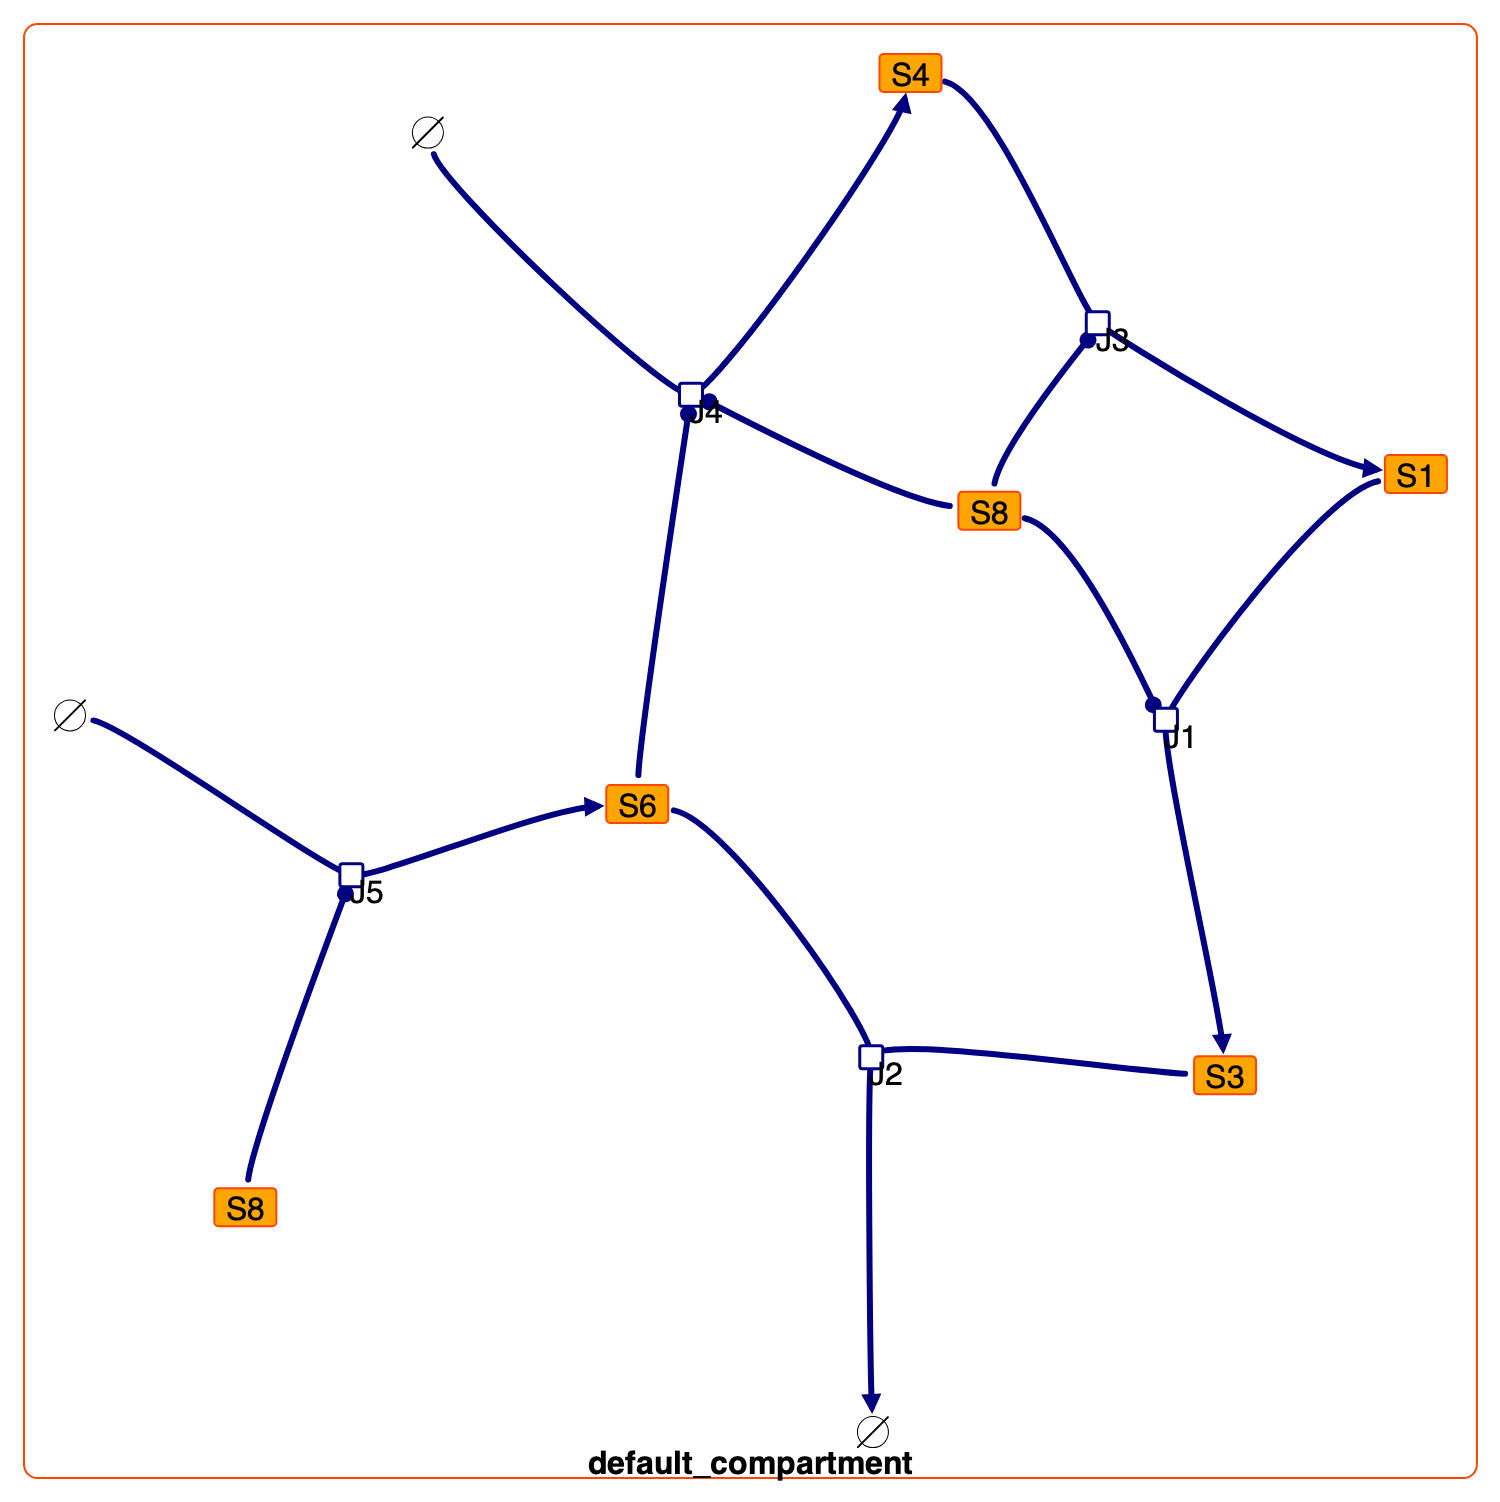

In [31]:
YEEJEE_NET1 = """
species S8

J1: S1 -> S3; 2.494728*S1*S8
J2: S3 + S6 -> ; 312.753091*S3*S6
J3: S4 -> S1; 3.957946*S4*S8
J4: -> S4; 8.787850*S6*S8
J5: -> S6; 3.993558*S8*S8

$S8 = 6
"""
simulate(YEEJEE_NET1)
draw(YEEJEE_NET1,"yj_net1_disc.png")

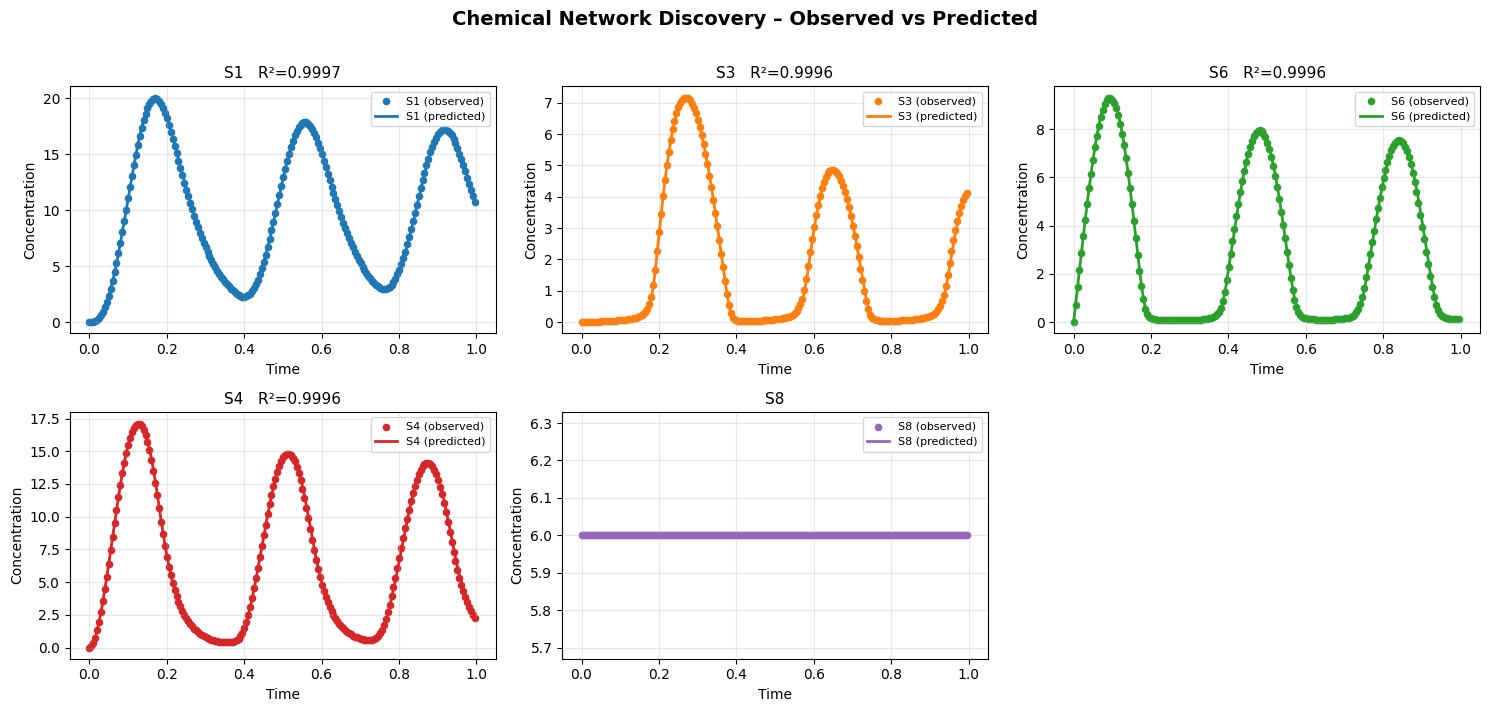

In [9]:
fit_result = fitNetwork(YEEJEE_NET1, end_time=1, poly_degree=2, num_point=1000, threshold=1)

In [10]:
fit_result.summary

,dS1/dt,dS3/dt,dS6/dt,dS4/dt,dS8/dt
1,4.630403e-09,-1.685770e-08,0.000000,4.063998e-09,0.000000e+00
S1 S8,-2.492331e+00,2.482336e+00,0.000000,0.000000e+00,2.760297e-15
S3 S6,0.000000e+00,-3.121890e+02,-312.189393,0.000000e+00,-1.748880e-13
S6 S8,0.000000e+00,0.000000e+00,0.000000,8.774914e+00,6.820267e-15
S4 S8,3.951337e+00,0.000000e+00,0.000000,-3.947491e+00,2.624921e-15
S8^2,0.000000e+00,0.000000e+00,3.989705,0.000000e+00,0.000000e+00


\begin{eqnarray}
\frac{d S_1}{dt} & = & -2.49 S_1 S_8 + 3.95 S_4 S_8 \\
\frac{d S_3}{dt} & = & 2.49 S_1 S_8 -312.2 S_3 S_6 \\
\frac{d S_6}{dt} & = & -312.2 S_3 S_6 + 3.98 S_8 S_8 \\
\frac{d S_4}{dt} & = & 8.77 S_6 S_8 - 3.95 S_4 S_8 \\
\frac{d S_8}{dt} & = & 0
\end{eqnarray}

In [11]:
fit_result.timecourse_df

,S1,S3,S6,S4,S8
time,,,,,
0.000000,0.000000,0.000000e+00,0.000000,0.000000,6.0
0.001001,0.000030,1.110157e-07,0.143912,0.003768,6.0
0.002002,0.000236,1.723617e-06,0.287824,0.014953,6.0
0.003003,0.000789,8.346046e-06,0.431735,0.033382,6.0
0.004004,0.001853,2.488810e-05,0.575645,0.058884,6.0
...,...,...,...,...,...
0.995996,10.699344,4.128092e+00,0.111717,2.241716,6.0
0.996997,10.592563,4.143248e+00,0.111273,2.194871,6.0
0.997998,10.486277,4.156852e+00,0.110874,2.149104,6.0


# Second Yeejee Oscillator

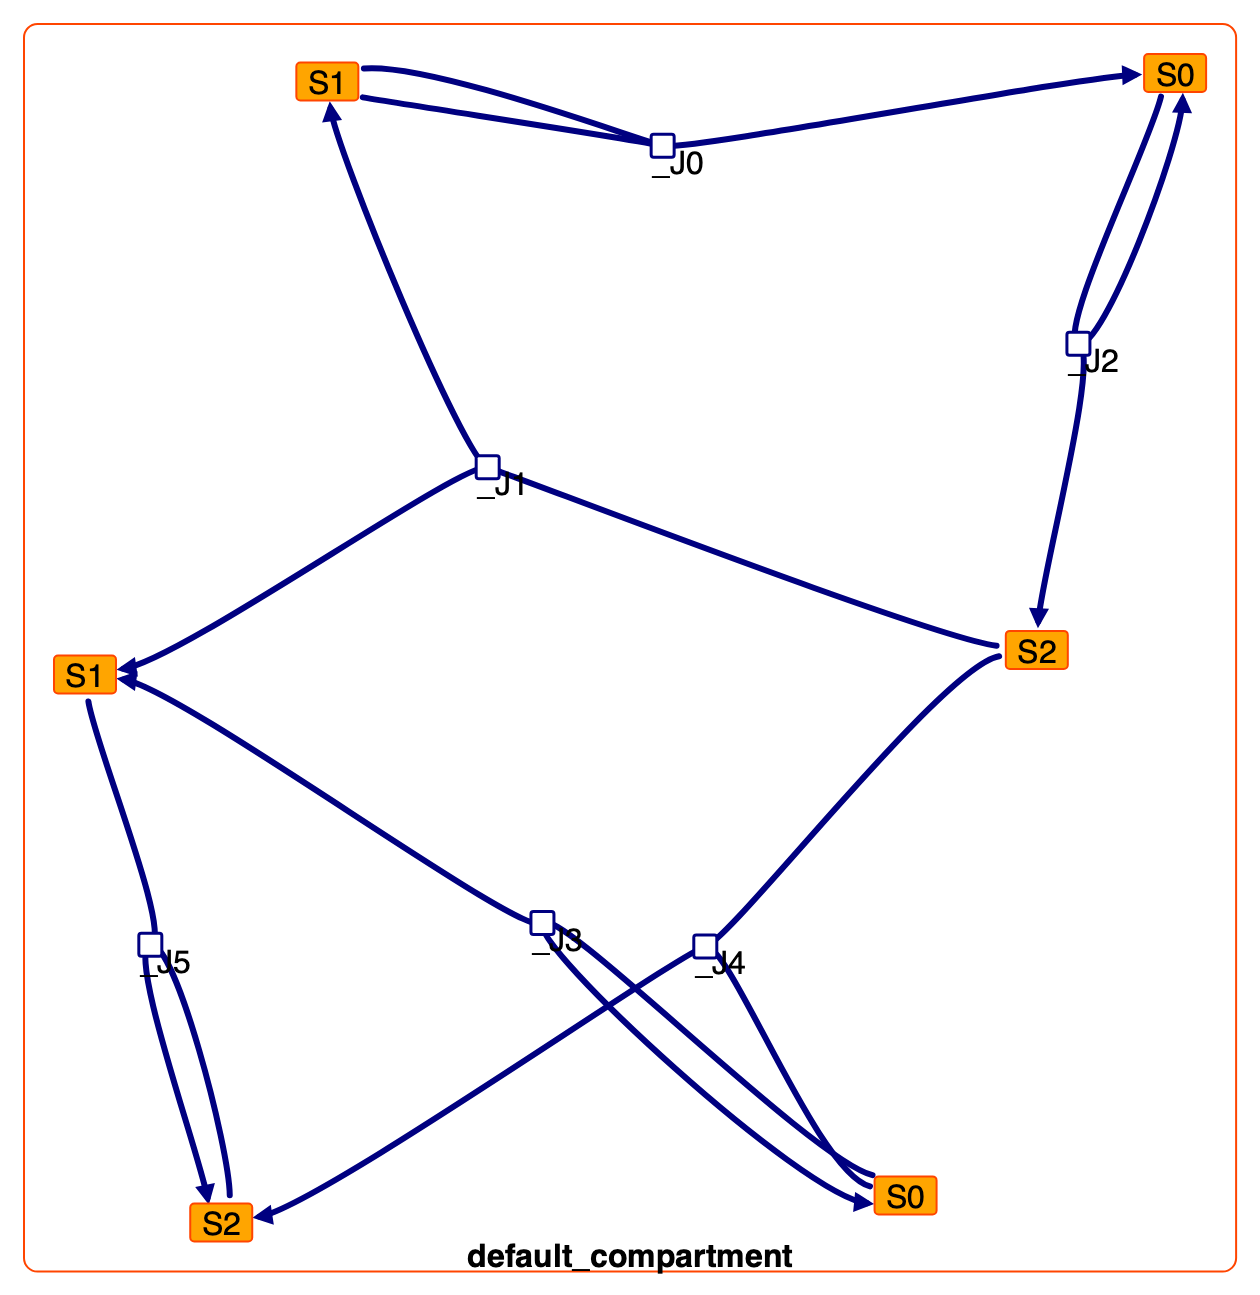

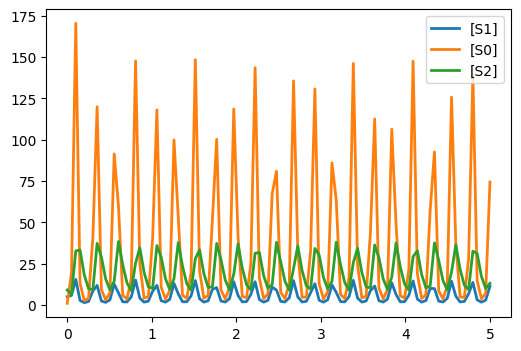

In [12]:
YEEJEE_NET2 = """
S1 + S1 -> S0; k1*S1*S1                                                                                                                                    
S2 -> S1 + S1; k2*S2
S0 -> S0 + S2; k3*S0
S0 -> S0 + S1; k4*S0
S0 + S2 -> S2; k5*S0*S2
S1 + S2 -> S2; k6*S1*S2
k1 = 46.216232606781
k2 = 13.632953893676342
k3 = 7.305742618829639
k4 = 231.36450415993264
k5 = 2.410490511912502
k6 = 36.793554130602736
S0 = 1.0
S1 = 5.0
S2 = 9.0
"""
draw(YEEJEE_NET2)
rr = te.loada(YEEJEE_NET2)
rr.simulate(0, 5, 100)
rr.plot()

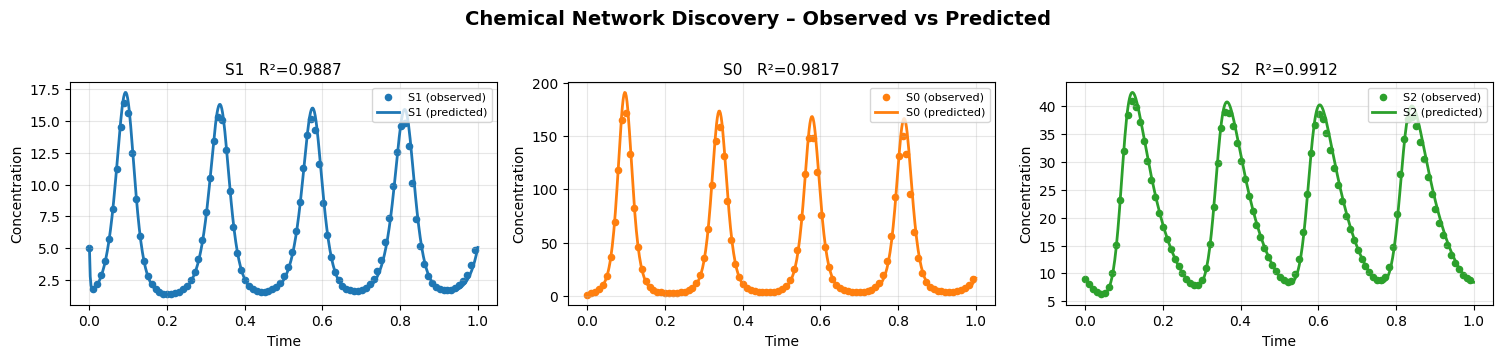

In [13]:
fit_result = fitNetwork(YEEJEE_NET2, end_time=1, poly_degree=2, num_point=500, threshold=2)

In [14]:
fit_result.summary

,dS1/dt,dS0/dt,dS2/dt
1,-57.445259,8.754110,0.000000
S1,26.615485,-8.267856,0.000000
S0,140.798973,31.711077,7.161390
S2,20.425803,3.885132,-13.705491
S1^2,-56.106273,34.419120,0.000000
S1 S2,-23.362971,-5.078233,0.000000
S0 S2,0.000000,-2.367988,0.000000


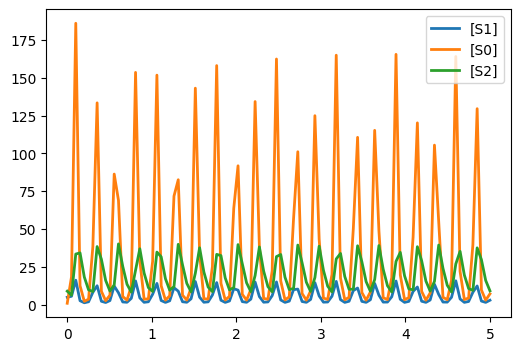

In [15]:
FIT_2 = """
J_1_S1: S1 -> ; k_1_S1
J_1_S0: -> S0 ; k_1_S0
J_S0: -> n_S0_S0 S0 + n_S0_S1 S1 + S2; k_S0*S0
J_S1: S0 -> n_S1_S1 S1; k_S1*S1
J_S2: n_S2_S2 S2 -> n_S2_S1 S1 + S0; k_S2*S2
J_S1S1: n_S1S1_S1 S1 -> S0; k_S1S1*S1*S1
J_S1S2: n_S1S2_S1 S1 + S0 ->; k_S1S2*S1*S2
J_S0S2: S0 -> ; k_S0S2*S0*S2


S1 = 5
S0 = 1
S2 = 9

k_1_S1 = 57.44529
k_1_S0 = 8.754

k_S1 = 8.267856
n_S1_S1 = 26.6154/k_S1

k_S0 = 7.161290
n_S0_S0 = 31.7117/k_S0
n_S0_S1 = 140.7988/k_S0

k_S2 = 3.885132
n_S2_S1 = 20.4258/k_S2
n_S2_S2 = 13.705/k_S2

k_S1S1 = 34.419
n_S1S1_S1 = 56.106/k_S1S1

k_S1S2 = 5.078233
n_S1S2_S1 = 23.3629/k_S1S2

k_S0S2 = 2.367
"""
rr = te.loada(FIT_2)
rr.simulate(0, 5, 100)
rr.plot()

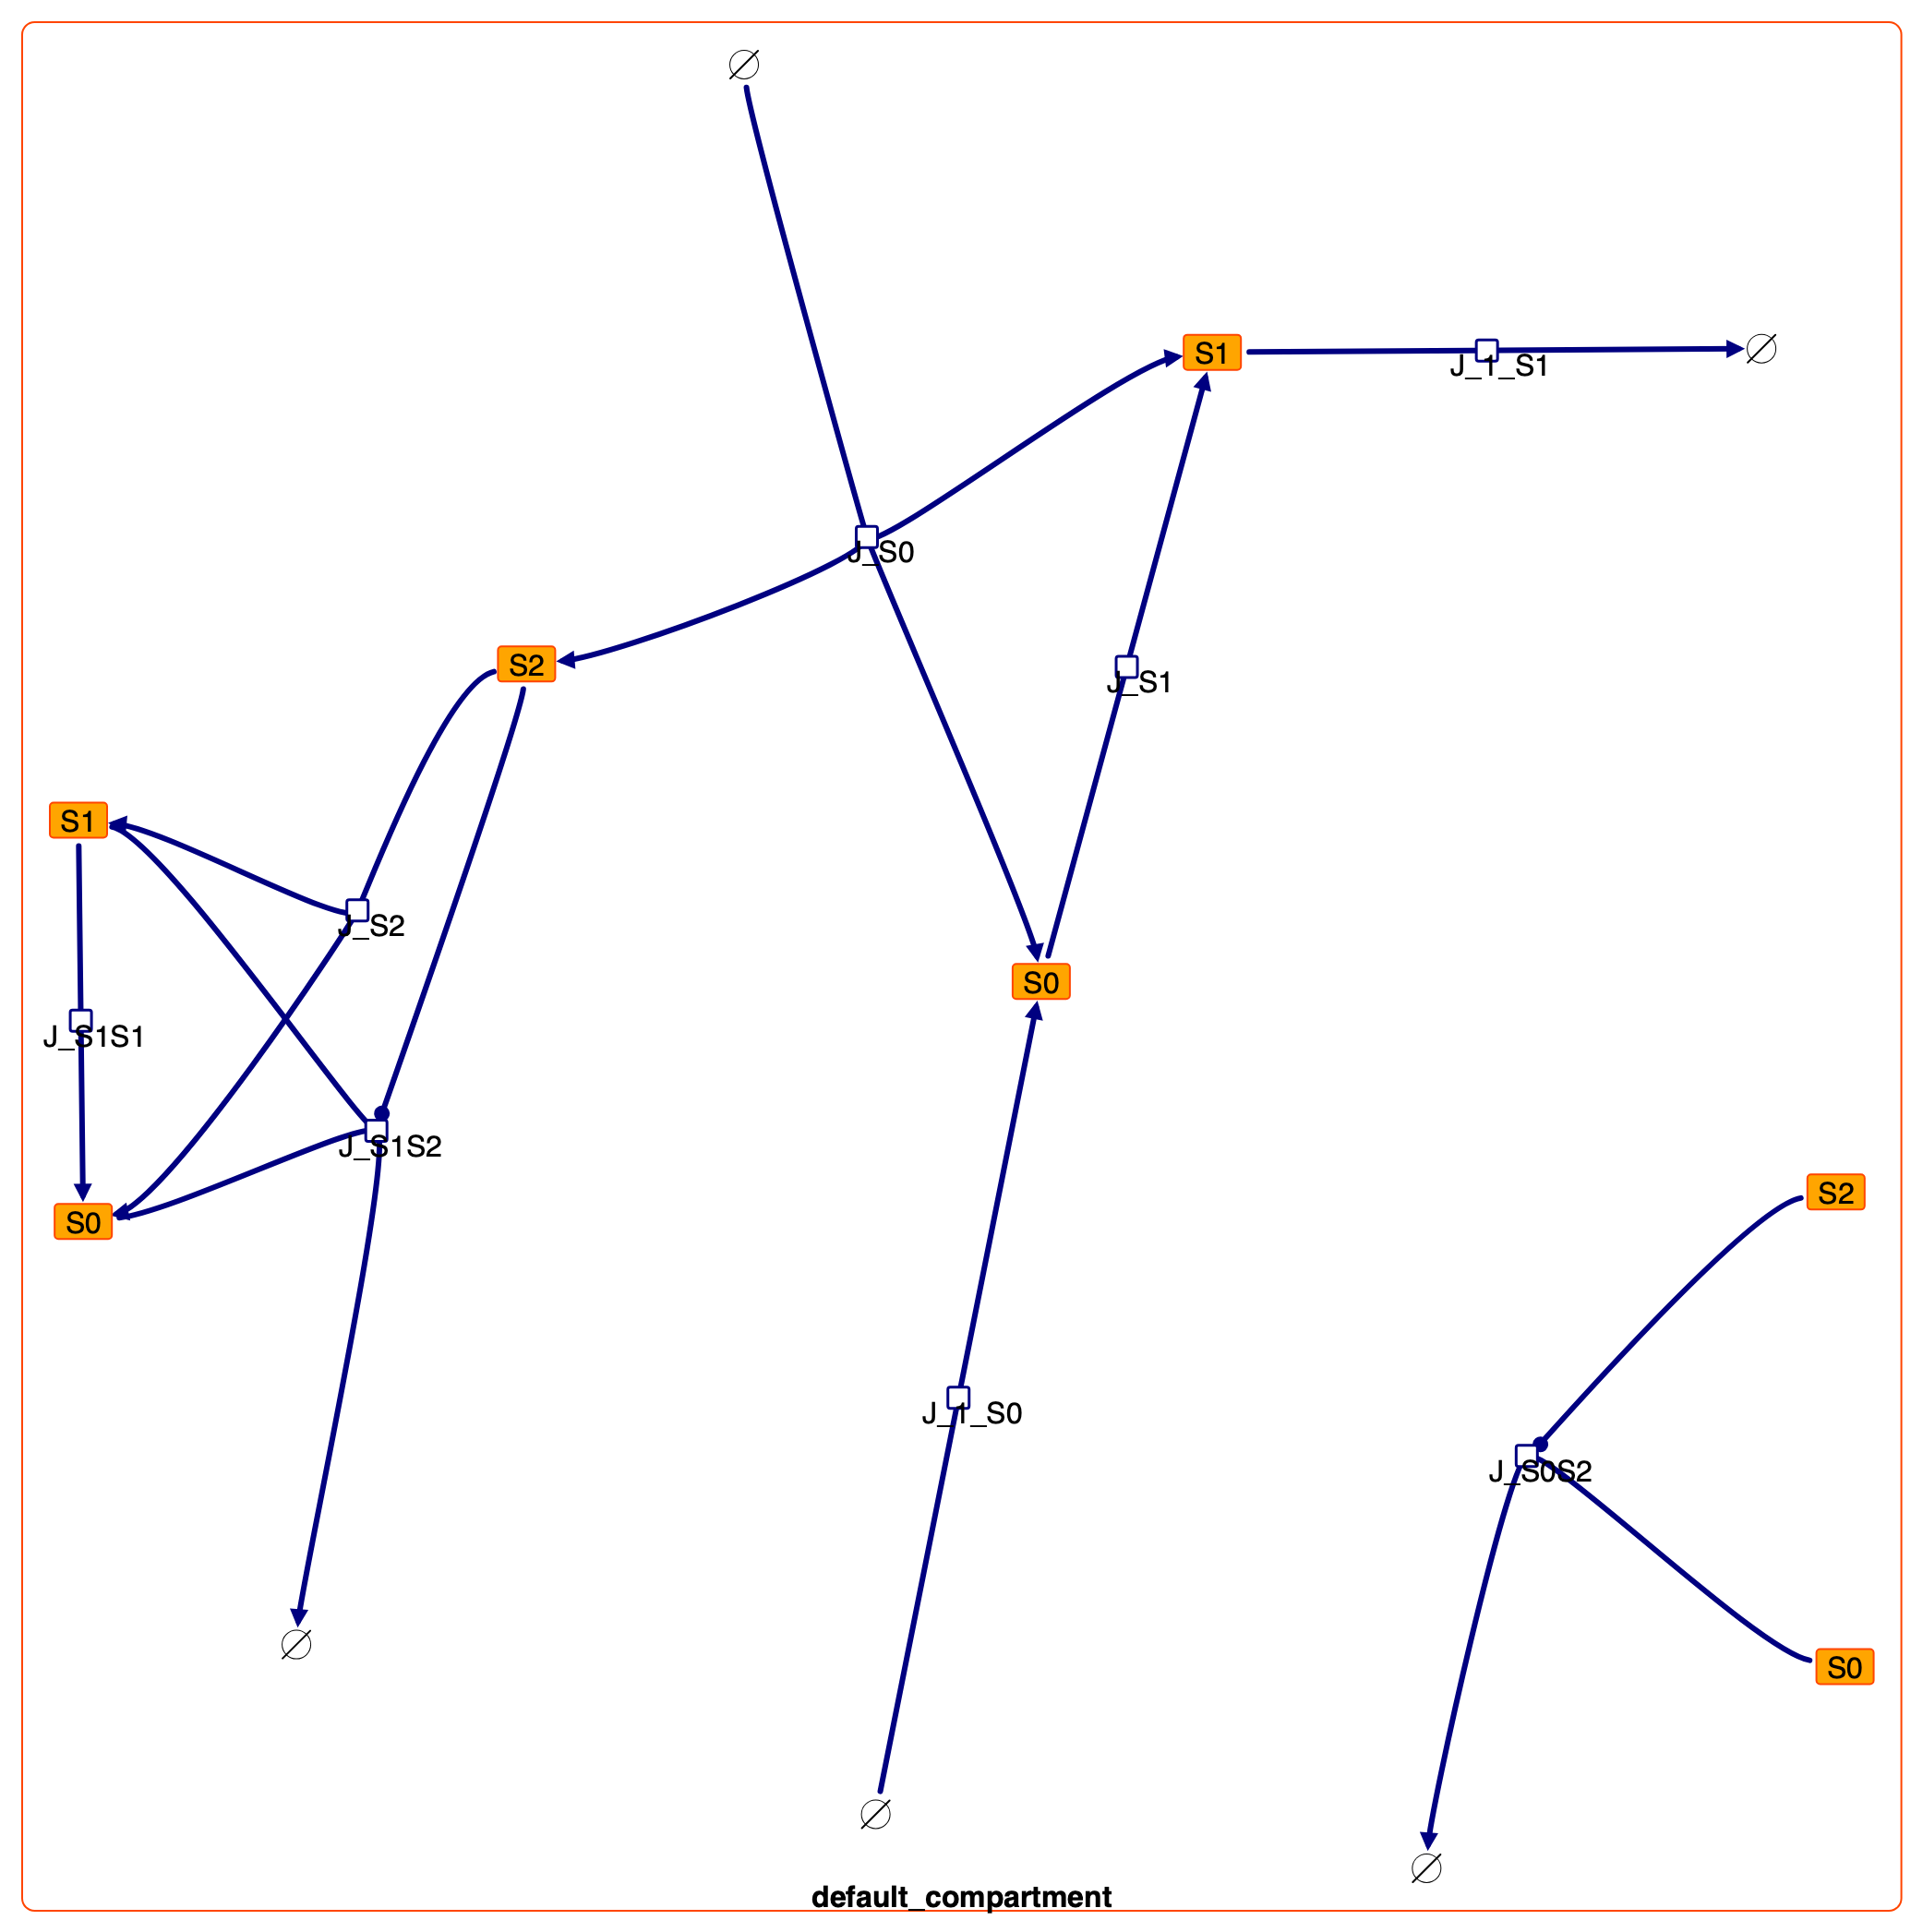

In [16]:
draw(FIT_2)